In [106]:
import sys, pathlib, importlib
from pprint import pprint

# Ensure we’re in the folder with utils.py
root = pathlib.Path.cwd()
print("CWD:", root)
assert (root / "utils.py").exists(), "This notebook is not in the same folder as utils.py"

# Make sure this folder is first on sys.path
sys.path.insert(0, str(root))

# Reload to pick up edits
import utils
importlib.reload(utils)

print("utils module file:", utils.__file__)
public = [a for a in dir(utils) if not a.startswith("_")]
print("attrs in utils:", public)

# Now import the classes
from utils import DRep, Delegator, utility,World

print(DRep, Delegator, utility)


CWD: /Users/Joel/Documents/GitHub/ada_drep/simulation
utils module file: /Users/Joel/Documents/GitHub/ada_drep/simulation/utils.py
attrs in utils: ['DRep', 'Delegator', 'List', 'Optional', 'Tuple', 'World', 'annotations', 'dataclass', 'field', 'random', 'utility']
<class 'utils.DRep'> <class 'utils.Delegator'> <function utility at 0x12886ea20>


In [107]:
# --- Tiny deterministic tests ---

class FakeRNG:
    """Feed a sequence of values for rng.random()."""
    def __init__(self, seq):
        self.seq = list(seq)
    def random(self):
        if not self.seq:
            return 1.0  # default high
        return self.seq.pop(0)

# Setup common actors
d1 = DRep(id="d1", opinion=0.30)
d2 = DRep(id="d2", opinion=0.75)
dreps = [d1, d2]

# 1) No improvement: Δu <= 0 => never switch
# Make current already best/closest (opinion near 0.75, current d2)
a = Delegator(id="a", opinion=0.76, s=0.0, current=d2)  # s=0, always reconsider
switched, cur = a.step(dreps, rng=FakeRNG([0.0, 0.0]))
assert switched is False and cur is d2, "Should not switch when Δu <= 0"

# 2) Improvement exists, but stickiness prevents reconsider (rng >= 1-s)
# opinion 0.80: best is d2, current d1 -> Δu = 0.45
b = Delegator(id="b", opinion=0.80, s=0.6, current=d1)
# First draw 0.8 >= 0.4 => do not reconsider; no second draw used
switched, cur = b.step(dreps, rng=FakeRNG([0.8]))
assert switched is False and cur is d1, "Stickiness should keep delegation"

# 3) Improvement exists, reconsider happens, but switch draw fails
c = Delegator(id="c", opinion=0.80, s=0.6, current=d1)
# First draw 0.1 < 0.4 => reconsider; second draw 0.9 >= 0.45 => stay
switched, cur = c.step(dreps, rng=FakeRNG([0.1, 0.9]))
assert switched is False and cur is d1, "Switch Bernoulli failed -> stay"

# 4) Improvement exists, reconsider happens, switch occurs


delegetor b maintained due to stickiness
delegetor c maintained due to utility


In [108]:
e = Delegator(id="e", opinion=0.80, s=0.6, current=d1)
# First draw 0.1 < 0.4 => reconsider; second draw 0.2 < 0.45 => switch
switched, cur = e.step(dreps, rng=FakeRNG([0.1, 0.2]))
assert switched is True and cur is d2, "Should switch to best DRep"

print("All deterministic checks passed.")


All deterministic checks passed.


In [109]:
import random
rng = random.Random(42)
trials = 10_000

switches = 0
for _ in range(trials):
    a = Delegator(id="a", opinion=0.80, s=0.2, current=d1)
    did, _ = a.step(dreps, rng=rng)
    switches += int(did)
print("Empirical P(switch) ~", switches / trials)


delegetor a maintained due to utility
delegetor a maintained due to stickiness
delegetor a maintained due to utility
delegetor a maintained due to utility
delegetor a maintained due to utility
delegetor a maintained due to utility
delegetor a maintained due to utility
delegetor a maintained due to utility
delegetor a maintained due to utility
delegetor a maintained due to stickiness
delegetor a maintained due to utility
delegetor a maintained due to stickiness
delegetor a maintained due to utility
delegetor a maintained due to utility
delegetor a maintained due to utility
delegetor a maintained due to stickiness
delegetor a maintained due to utility
delegetor a maintained due to utility
delegetor a maintained due to stickiness
delegetor a maintained due to utility
delegetor a maintained due to utility
delegetor a maintained due to stickiness
delegetor a maintained due to stickiness
delegetor a maintained due to utility
delegetor a maintained due to utility
delegetor a maintained due to

In [110]:
# --- Direct voting: one epoch outcome ---

def direct_vote_epoch(delegators, weighted: bool = True):
    """
    Returns (approved: bool, approve_weight: float, reject_weight: float).
    Rule: approve iff O_t(i) in [0, 0.5], else reject. Votes come from delegators only.
    """
    approve_w = 0.0
    reject_w  = 0.0
    for d in delegators:
        w = d.stake if weighted else 1.0
        if 0.0 <= d.opinion <= 0.5:
            approve_w += w
        else:
            reject_w += w
    return (approve_w >= reject_w, approve_w, reject_w)


In [111]:
# --- Delegated voting: one epoch outcome, given current delegations ---

def delegated_vote_epoch(world, weighted: bool = True):
    """
    Uses DReps' opinions and their W'_t weights (own stake + delegated stake).
    Returns (approved: bool, approve_weight: float, reject_weight: float).
    """
    # Recompute W' quickly (mirrors World.epoch logic)
    Wprime = {d.id: d.stake for d in world.dreps}
    for delegator in world.delegators:
        if delegator.current is not None:
            Wprime[delegator.current.id] += delegator.stake

    approve_w = 0.0
    reject_w  = 0.0
    for d in world.dreps:
        w = Wprime[d.id] if weighted else 1.0
        if 0.0 <= d.opinion <= 0.5:
            approve_w += w
        else:
            reject_w += w
    return (approve_w >= reject_w, approve_w, reject_w),Wprime


In [112]:
# --- Opinion dynamics for DReps: uniform shift right, cap at 1 ---

def shift_dreps_uniform(world, x: float):
    """
    In each epoch, add x > 0 to each DRep's opinion and cap at 1.0.
    """
    for d in world.dreps:
        d.opinion = min(1.0, d.opinion + x)


In [113]:
from copy import deepcopy

def run_epoch_benchmarks(initial_world, rng, shift_x: float = 0.0, weighted: bool = True):
    """
    Runs one epoch:
      - Delegators may redelegate (per your World.epoch / Delegator.step rules)
      - Compute 'direct voting' outcome (delegators only)
      - Compute 'delegated voting' outcome (DReps with W')
      - Optionally shift DRep opinions by shift_x after the vote (for next epoch)
    Returns a dict with both outcomes and internal tallies.
    """
    # Work on the same world object (mutates it) — or deepcopy if you prefer stateless
    world = initial_world

    # 1) Delegators update (redelegation)
    world.epoch()  # uses world.rng already; if you want to force rng, set world.rng = rng

    # 2) Outcomes this epoch
    direct_ok, direct_yes, direct_no = direct_vote_epoch(world.delegators, weighted=weighted)
    delegated_ok, del_yes, del_no = delegated_vote_epoch(world, weighted=weighted)

    result = {
        "direct":    {"approved": direct_ok,   "approve_weight": direct_yes, "reject_weight": direct_no},
        "delegated": {"approved": delegated_ok,"approve_weight": del_yes,    "reject_weight": del_no},
    }

    # 3) Evolve DRep opinions for next epoch (uniform shift)
    if shift_x > 0.0:
        shift_dreps_uniform(world, shift_x)

    return result


In [114]:
def simulate_benchmarks(
    init_world,
    epochs: int = 10,
    runs: int = 20,
    shift_x: float = 0.0,
    weighted: bool = True,
    seed: int = 1234,
):
    """
    Repeats a benchmark comparison for multiple runs and epochs.
    Returns a list of runs; each run is a list of epoch result dicts.
    """
    all_runs = []
    base_dreps = deepcopy(init_world.dreps)
    base_delegators = deepcopy(init_world.delegators)

    for r in range(runs):
        # fresh world for each run
        rng = random.Random(seed + r)
        world = World(
            dreps=deepcopy(base_dreps),
            delegators=deepcopy(base_delegators),
            rng=rng
        )
        run_results = []
        for e in range(epochs):
            res = run_epoch_benchmarks(world, rng, shift_x=shift_x, weighted=weighted)
            run_results.append(res)
        all_runs.append(run_results)

    return all_runs


In [115]:
# Example initial world (tweak as you like)
dreps = [DRep("d1", 0.30, stake=10.0), DRep("d2", 0.75, stake=10.0)]
delegators = [
    Delegator("a1", 0.80, stake=5.0,  s=0.6, current=dreps[0]),
    Delegator("a2", 0.20, stake=3.0,  s=0.4, current=dreps[0]),
    Delegator("a3", 0.55, stake=2.0,  s=0.3, current=dreps[1]),
    Delegator("a4", 0.10, stake=1.0,  s=0.8, current=dreps[1]),
]

world0 = World(dreps=dreps, delegators=delegators, rng=random.Random(42))

results = simulate_benchmarks(
    world0, epochs=100, runs=5, shift_x=0.01, weighted=True, seed=2025
)

# Quick peek at the first run's epoch-by-epoch outcomes

for t, r in enumerate(results[0], start=1):
    print(f"Epoch {t:02d} | direct: {r['direct']} | delegated: {r['delegated']}")


delegetor a1 maintained due to stickiness
delegetor a4 maintained due to stickiness


ValueError: not enough values to unpack (expected 3, got 2)

In [116]:
def aggregate_approval_rates(results):
    """
    results: output of simulate_benchmarks
    Returns: dict with 'direct' and 'delegated' approval rates per epoch.
    """
    runs = len(results)
    epochs = len(results[0])
    acc_direct = [0]*epochs
    acc_deleg  = [0]*epochs

    for run in results:
        for e, r in enumerate(run):
            acc_direct[e] += int(r["direct"]["approved"])
            acc_deleg[e]  += int(r["delegated"]["approved"])

    return {
        "direct":   [x / runs for x in acc_direct],
        "delegated":[x / runs for x in acc_deleg],
    }

agg = aggregate_approval_rates(results)
print("Approval rate per epoch (direct):   ", agg["direct"])
print("Approval rate per epoch (delegated):", agg["delegated"])


Approval rate per epoch (direct):    [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
Approval rate per epoch (delegated): [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


In [130]:
# --- Simulation scale/config ---
N_DREPS       = 5
N_DELEGATORS  = 20
EPOCHS        = 50
RUNS          = 1
SHIFT_X       = 0.02    # uniform right shift of DRep opinions per epoch (cap at 1)
WEIGHTED      = True
SEED          = 2025



In [136]:
import random
from math import exp
from copy import deepcopy

rng_global = random.Random(SEED)

def sample_opinion_drep(rng):
    return rng.random()


def sample_opinion_delegator(rng):
    # Delegator opinions: uniform in [0,1]
    return rng.random()

def sample_stake(rng):
    # Stake: log-normal-ish spread, rescaled a bit
    # mean around ~1 with long tail
    val = exp(rng.gauss(0.0, 1.0))
    return 0.5 + 0.5*val  # shift up a bit

def sample_stickiness(rng):
    return 1  # Uniform[0,1]

def init_world_large(rng):
    # Create DReps
    dreps = []
    for k in range(N_DREPS):
        dreps.append(DRep(
            id=f"d{k+1}",
            opinion=max(0.0, min(1.0, sample_opinion_drep(rng))),
            stake=sample_stake(rng)
        ))
    # Create delegators
    delegators = []
    for k in range(N_DELEGATORS):
        op = sample_opinion_delegator(rng)
        s  = sample_stickiness(rng)
        st = sample_stake(rng)
        # assign initial delegation to closest DRep
        # (we pass a temporary Delegator to use closest_drep logic less)
        d_tmp = Delegator(id=f"a{k+1}", opinion=op, stake=st, s=s, current=None)
        closest = d_tmp.closest_drep(dreps)
        delegators.append(Delegator(
            id=f"a{k+1}",
            opinion=op,
            stake=st,
            s=s,
            current=closest
        ))
    return World(dreps=dreps, delegators=delegators, rng=rng)


In [137]:
def run_epoch_benchmarks(world, shift_x: float = 0.0, weighted: bool = True):
    """
    1) Delegators may redelegate.
    2) Compute outcomes for direct vs delegated voting.
    3) Return outcome + some diagnostics (W' distribution, fraction switched).
    4) Optionally shift DReps' opinions by shift_x.
    """
    # before epoch, snapshot current delegations for switch rate
    prev_map = {d.id: d.current.id if d.current else None for d in world.delegators}

    world.epoch()  # redelegations may occur

    # fraction switched this epoch
    cur_map = {d.id: d.current.id if d.current else None for d in world.delegators}
    switched_frac = sum(prev_map[k] != cur_map[k] for k in prev_map) / len(prev_map)

    direct, = (direct_vote_epoch(world.delegators, weighted=weighted),)
    delegated, Wprime = delegated_vote_epoch(world, weighted=weighted)

    # shift dreps for next epoch
    if shift_x > 0.0:
        shift_dreps_uniform(world, shift_x)

    return {
        "switched_frac": switched_frac,
        "direct":    {"approved": direct[0],    "approve_weight": direct[1],    "reject_weight": direct[2]},
        "delegated": {"approved": delegated[0], "approve_weight": delegated[1], "reject_weight": delegated[2]},
        "Wprime": Wprime,
        "dreps_opinions": {d.id: d.opinion for d in world.dreps},
    }


In [ ]:
def simulate_large(
    epochs=EPOCHS, runs=RUNS, shift_x=SHIFT_X, weighted=WEIGHTED, seed=SEED
):
    all_runs = []
    for r in range(runs):
        rng = random.Random(seed + r)
        world = init_world_large(rng)
        run_metrics = []
        for e in range(epochs):
            res = run_epoch_benchmarks(world, shift_x=shift_x, weighted=weighted)
            run_metrics.append(res)
            world.plot_opinions(draw_edges=True)

        all_runs.append(run_metrics)
    return all_runs

def aggregate_metrics():
    runs = len(all_runs)
    epochs = len(all_runs[0])

    # Aggregates
    direct_rate   = [0.0]*epochs
    delegated_rate= [0.0]*epochs
    switched_frac = [0.0]*epochs

    # Optionally: average concentration of W' (e.g., top-5 share)
    top5_share = [0.0]*epochs

    for run in all_runs:
        for e, res in enumerate(run):
            direct_rate[e]    += 1.0 if res["direct"]["approved"] else 0.0
            delegated_rate[e] += 1.0 if res["delegated"]["approved"] else 0.0
            switched_frac[e]  += res["switched_frac"]

            # compute top-5 share of W'
            Wp = res["Wprime"]
            tot = sum(Wp.values())
            if tot > 0:
                top5 = sorted(Wp.values(), reverse=True)[:5]
                top5_share[e] += sum(top5)/tot
            else:
                top5_share[e] += 0.0

    # average across runs
    direct_rate    = [x/runs for x in direct_rate]
    delegated_rate = [x/runs for x in delegated_rate]
    switched_frac  = [x/runs for x in switched_frac]
    top5_share     = [x/runs for x in top5_share]

    return {
        "direct_rate": direct_rate,
        "delegated_rate": delegated_rate,
        "switched_frac": switched_frac,
        "top5_share": top5_share,
    }


delegetor a3 maintained due to stickiness
delegetor a16 maintained due to stickiness
delegetor a3 maintained due to stickiness
delegetor a16 maintained due to stickiness
delegetor a2 maintained due to stickiness
delegetor a3 maintained due to stickiness
delegetor a8 maintained due to stickiness
delegetor a9 maintained due to stickiness
delegetor a12 maintained due to stickiness
delegetor a16 maintained due to stickiness
delegetor a2 maintained due to stickiness
delegetor a3 maintained due to stickiness
delegetor a8 maintained due to stickiness
delegetor a9 maintained due to stickiness
delegetor a10 maintained due to stickiness
delegetor a12 maintained due to stickiness
delegetor a16 maintained due to stickiness
delegetor a2 maintained due to stickiness
delegetor a3 maintained due to stickiness
delegetor a8 maintained due to stickiness
delegetor a9 maintained due to stickiness
delegetor a10 maintained due to stickiness
delegetor a12 maintained due to stickiness
delegetor a16 maintained 

/Users/Joel/Documents/GitHub/ada_drep/simulation/utils.py:189: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.


delegetor a2 maintained due to stickiness
delegetor a3 maintained due to stickiness
delegetor a4 maintained due to stickiness
delegetor a5 maintained due to stickiness
delegetor a7 maintained due to stickiness
delegetor a8 maintained due to stickiness
delegetor a9 maintained due to stickiness
delegetor a10 maintained due to stickiness
delegetor a11 maintained due to stickiness
delegetor a12 maintained due to stickiness
delegetor a13 maintained due to stickiness
delegetor a14 maintained due to stickiness
delegetor a15 maintained due to stickiness
delegetor a16 maintained due to stickiness
delegetor a17 maintained due to stickiness
delegetor a18 maintained due to stickiness
delegetor a19 maintained due to stickiness
delegetor a20 maintained due to stickiness
delegetor a2 maintained due to stickiness
delegetor a3 maintained due to stickiness
delegetor a4 maintained due to stickiness
delegetor a5 maintained due to stickiness
delegetor a7 maintained due to stickiness
delegetor a8 maintained

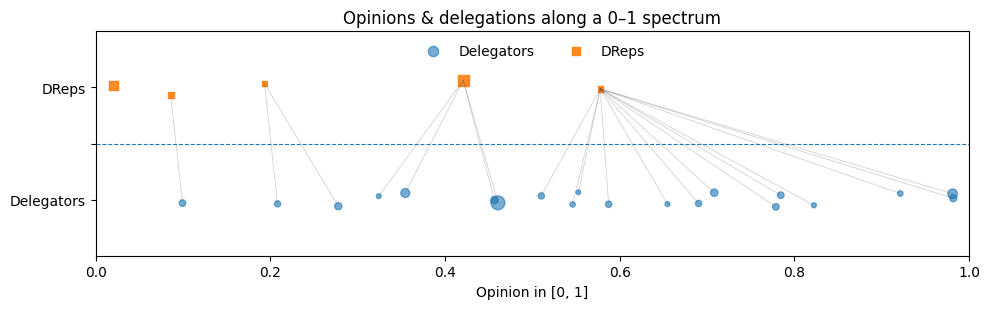

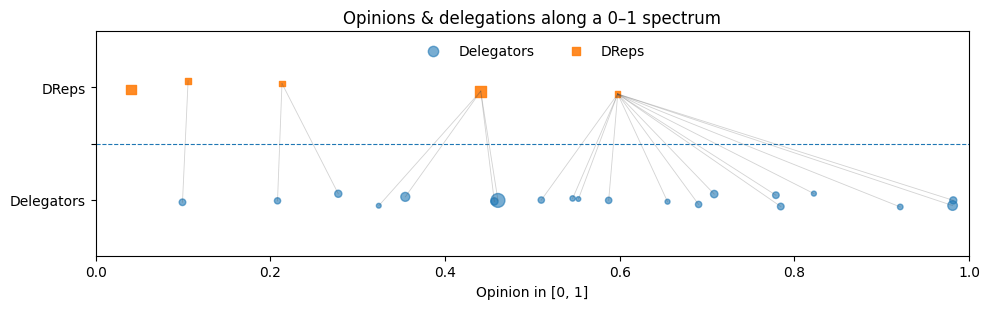

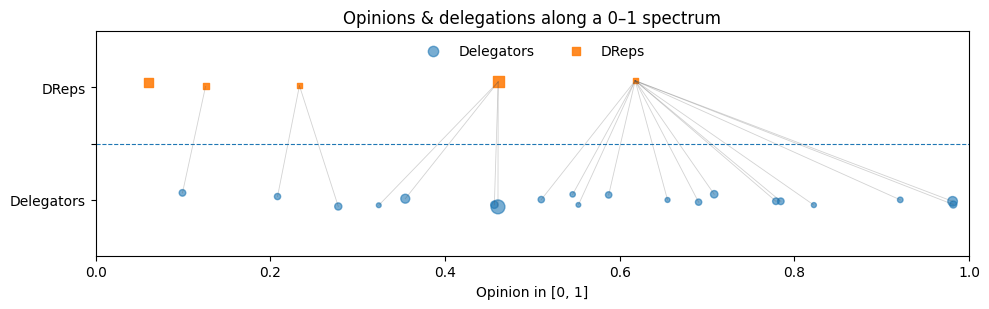

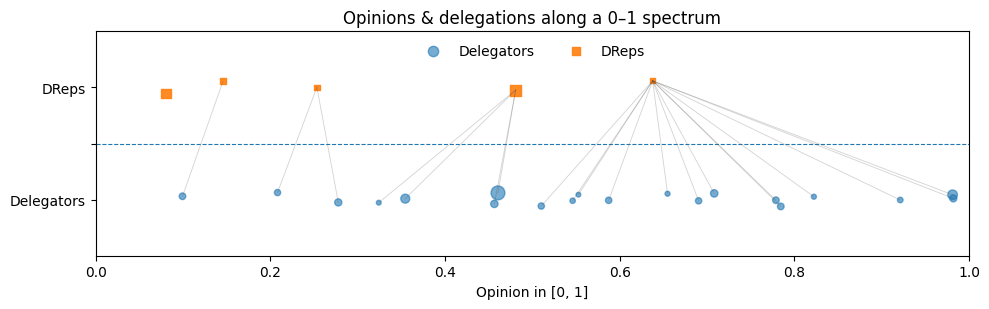

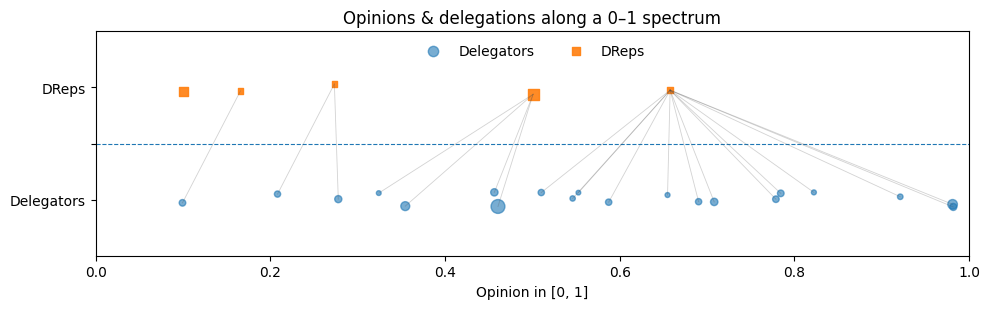

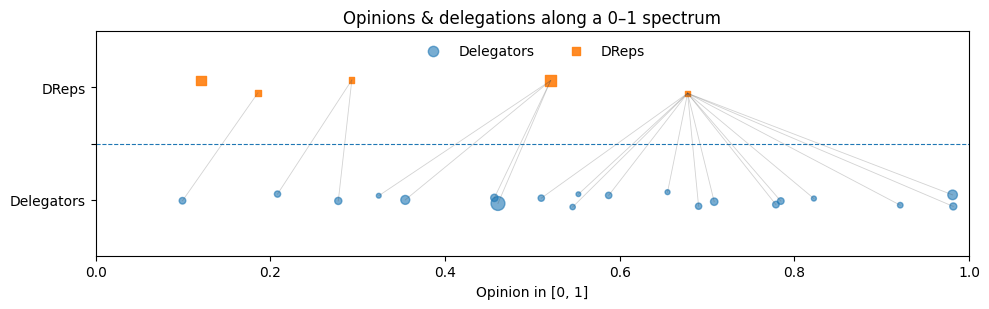

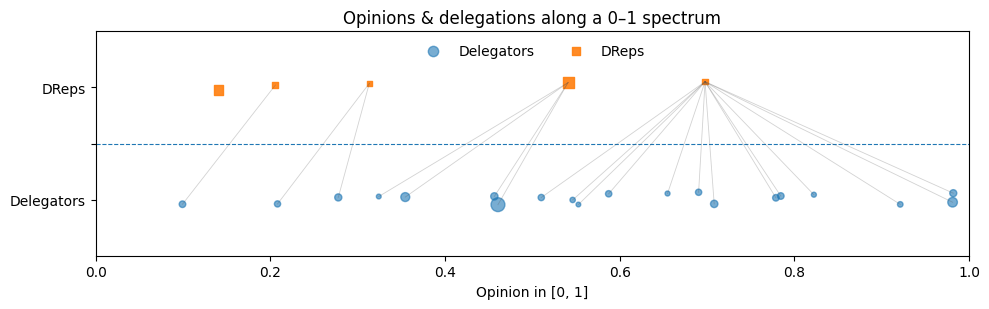

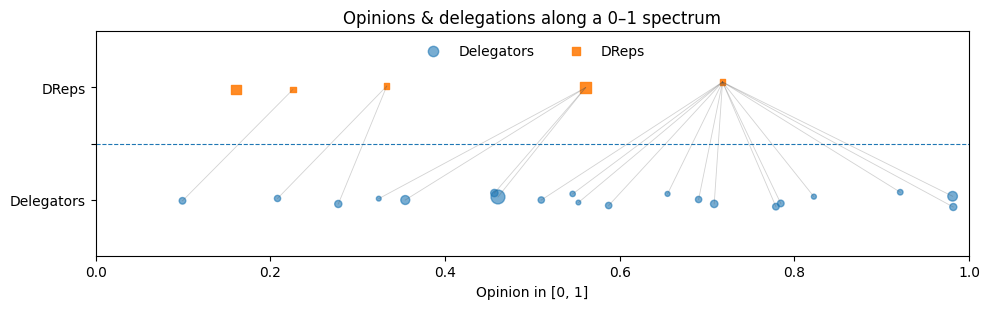

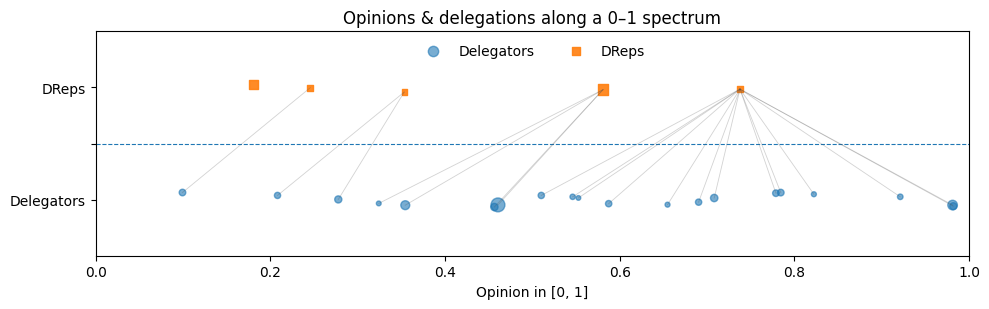

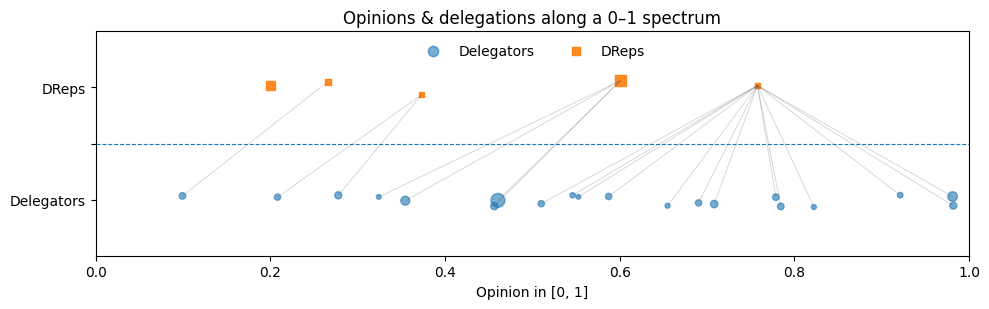

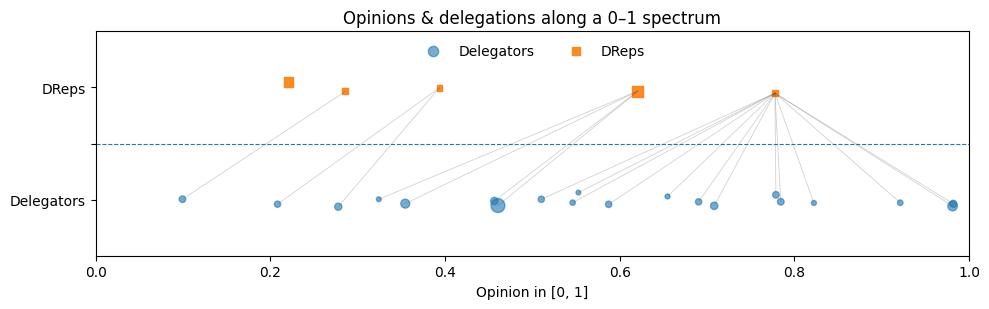

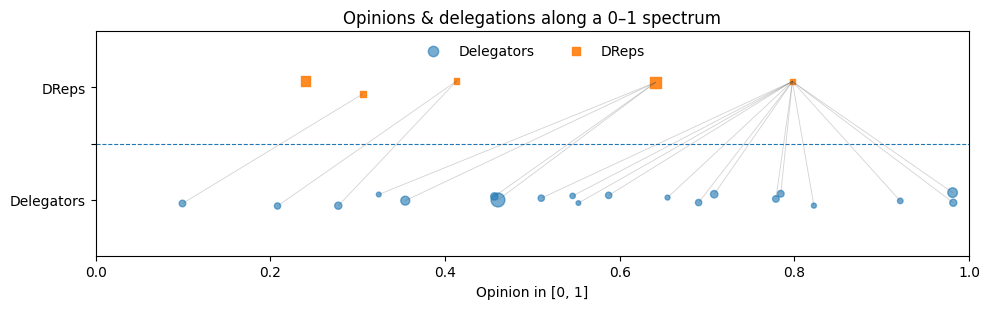

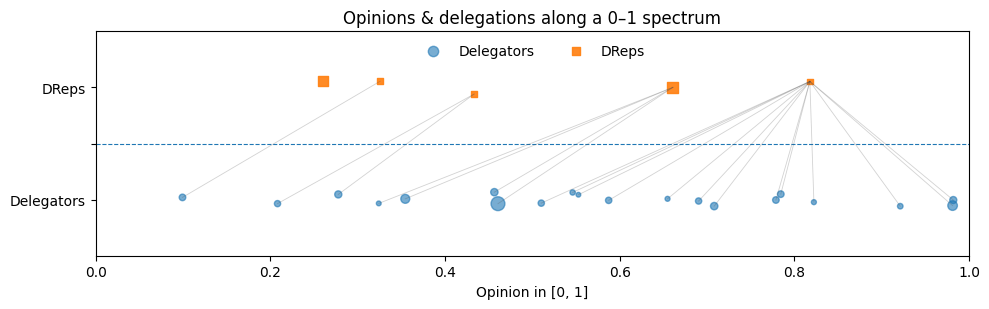

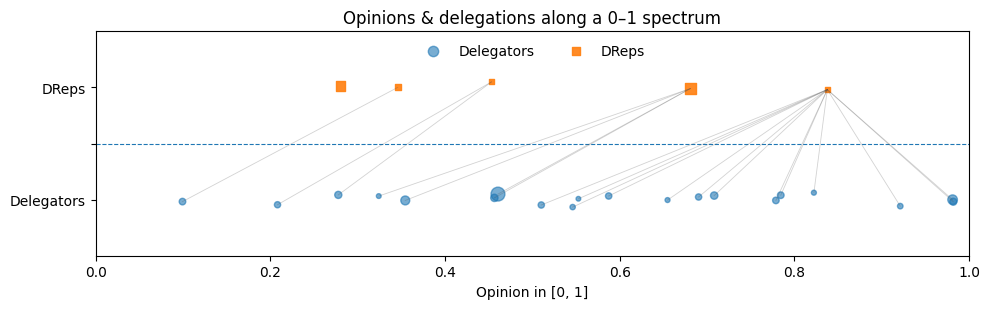

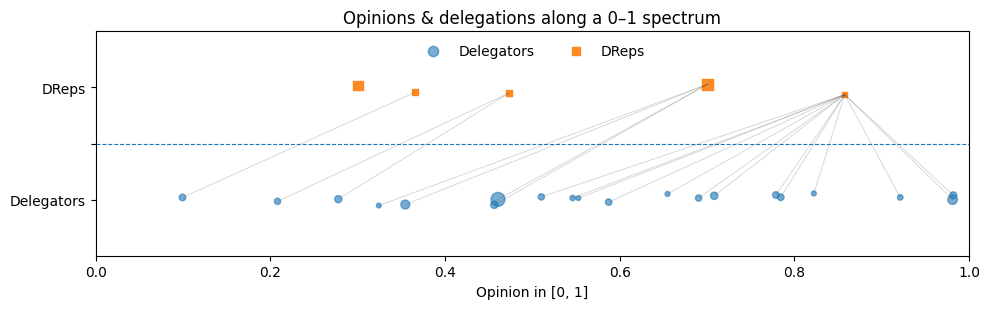

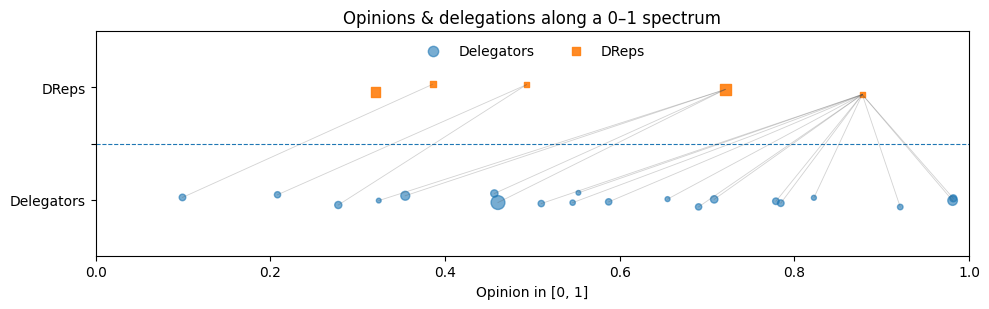

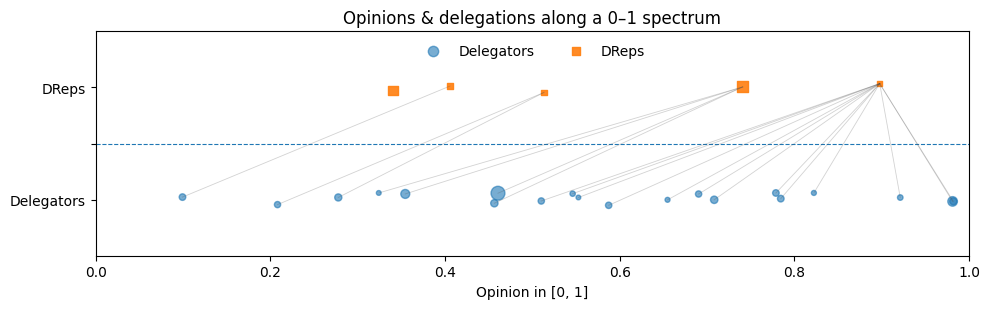

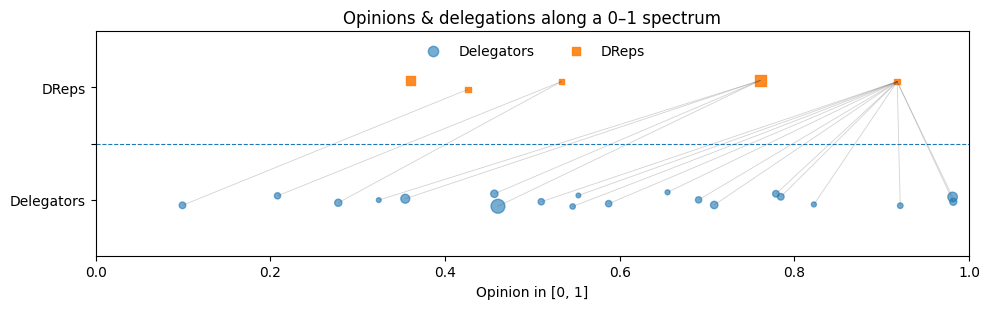

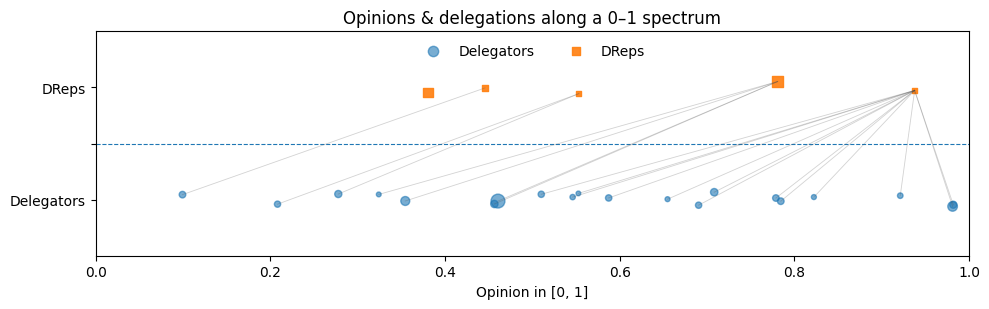

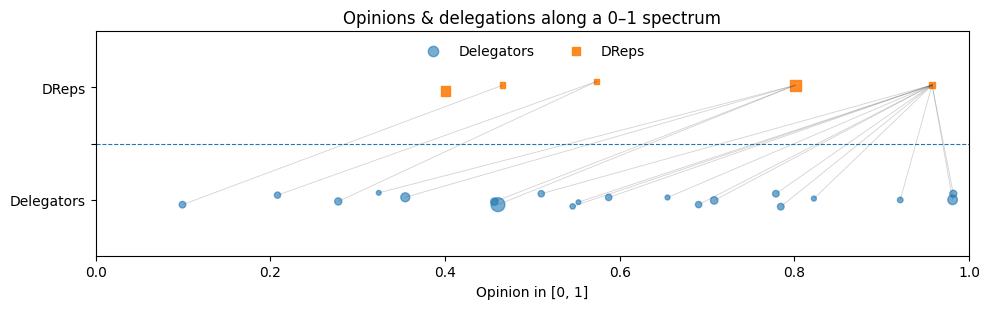

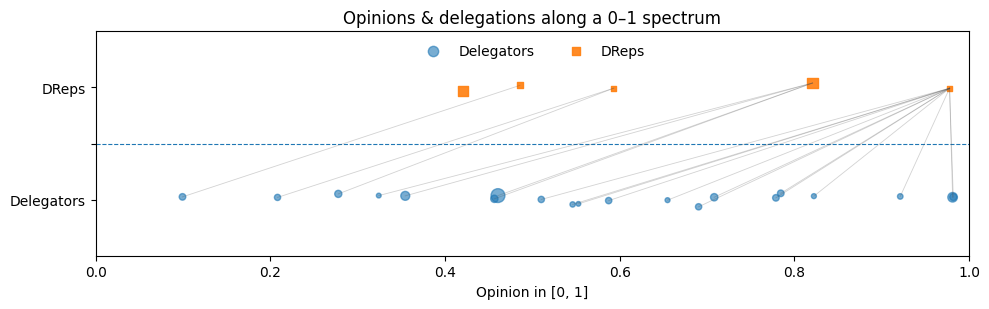

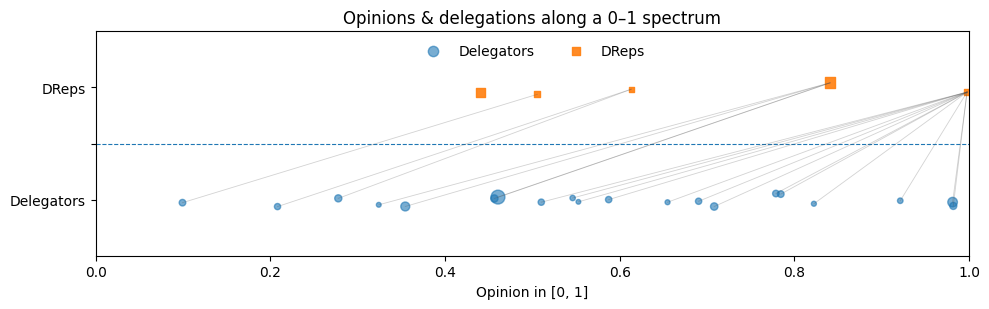

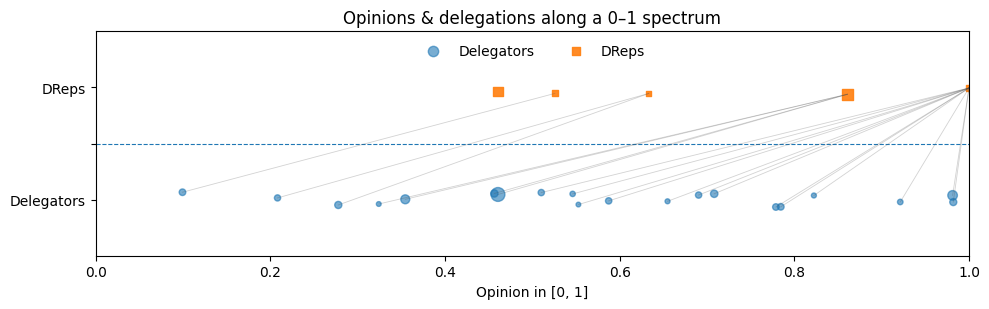

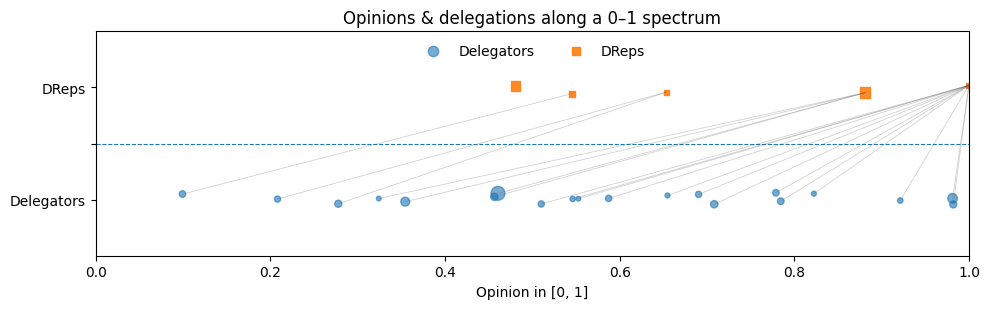

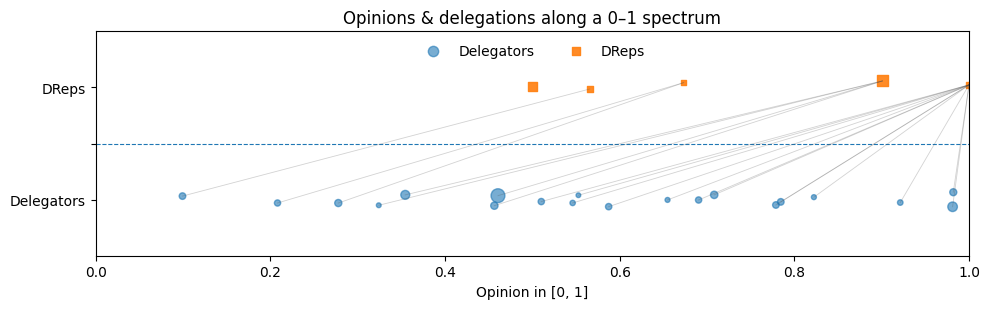

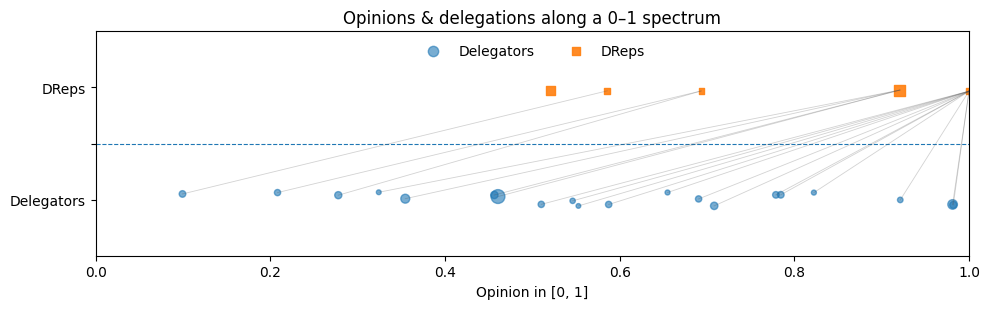

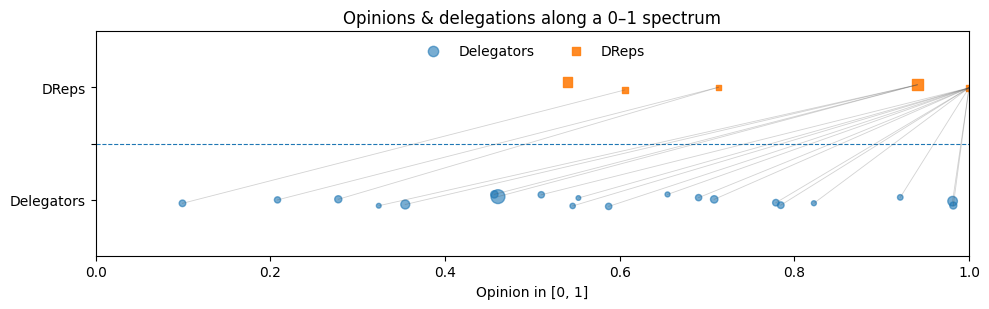

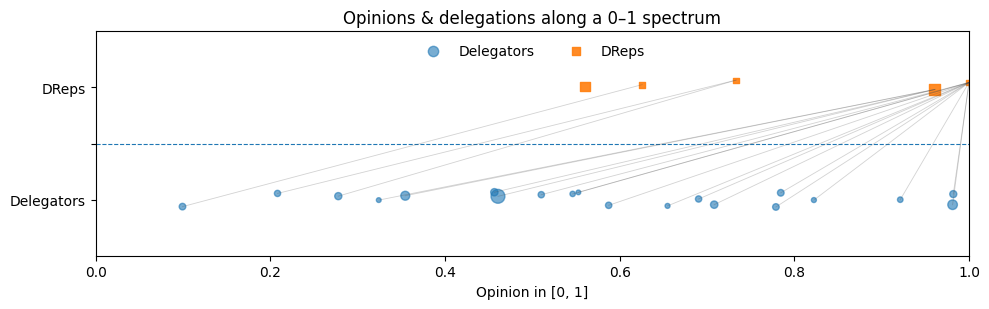

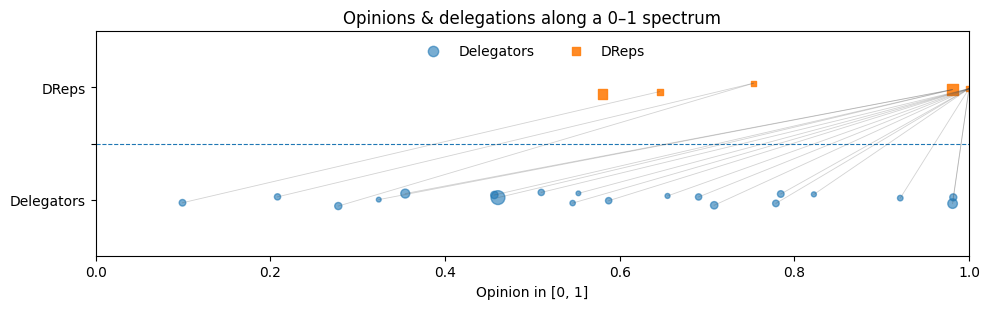

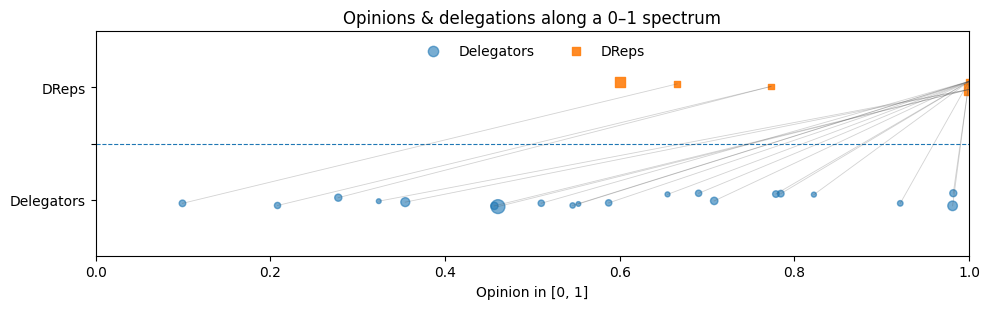

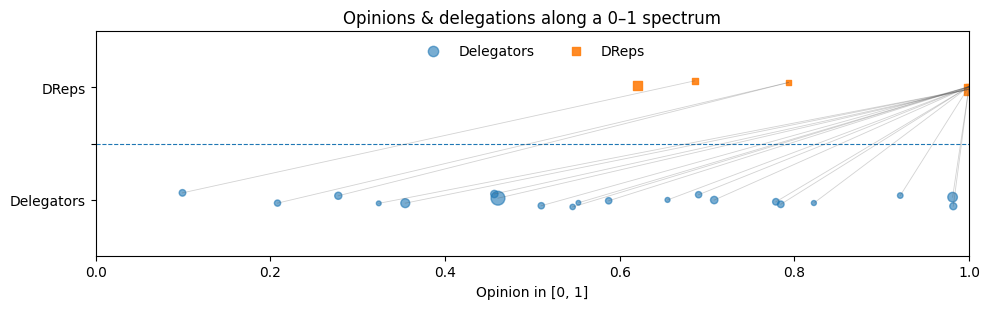

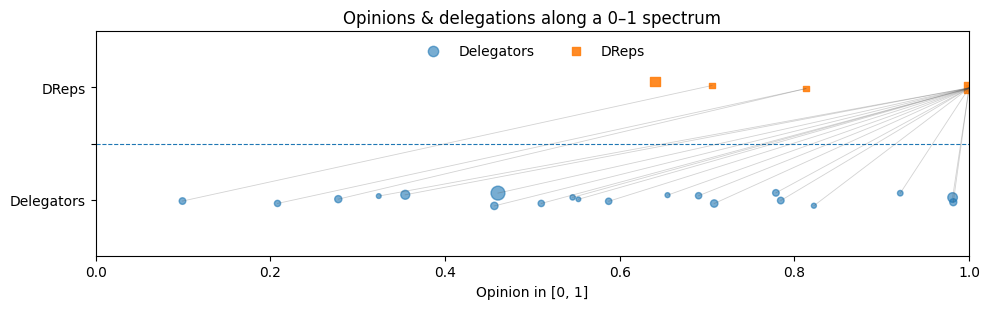

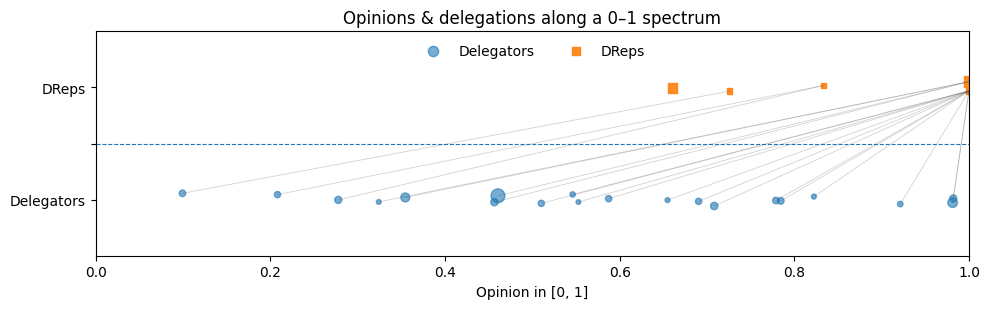

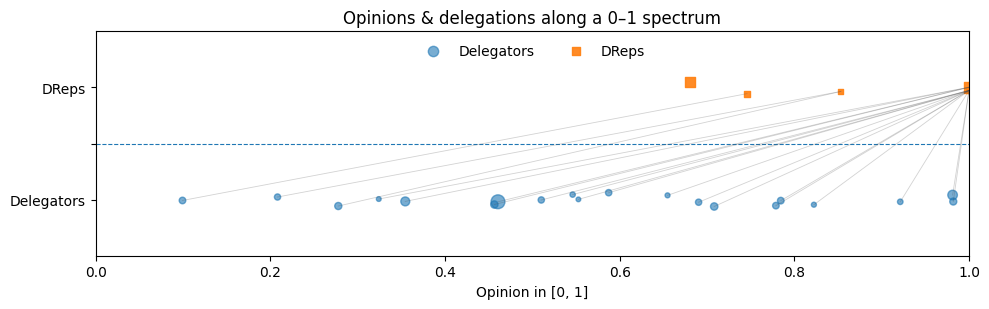

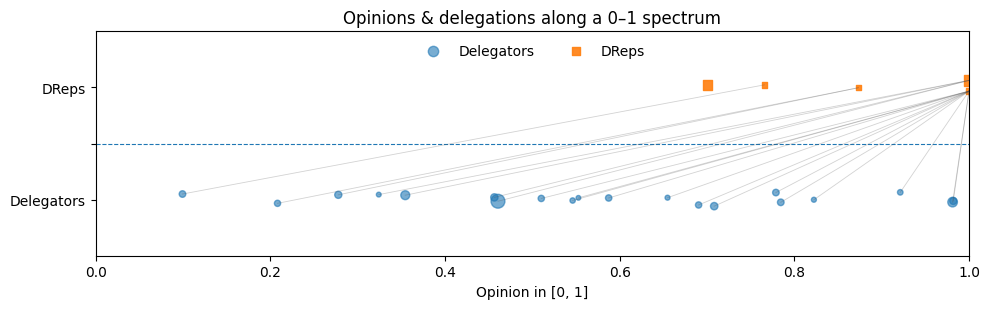

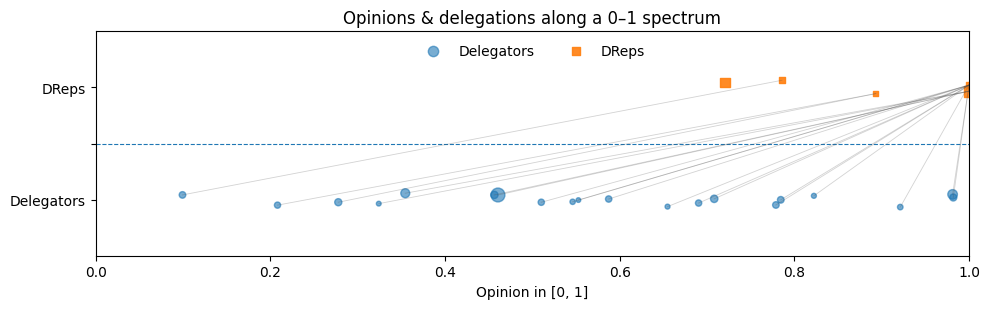

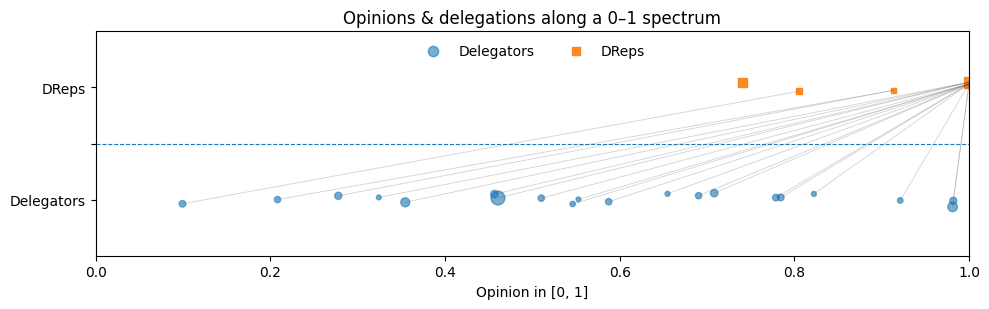

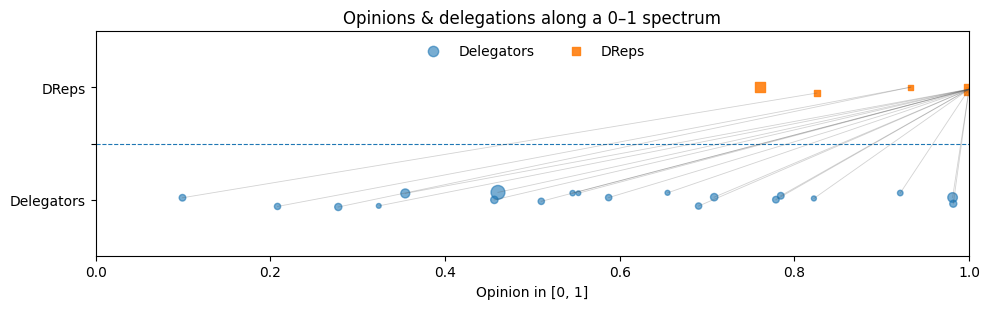

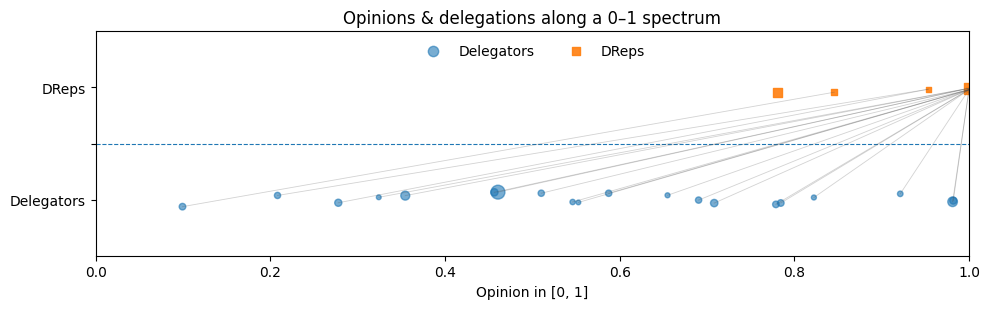

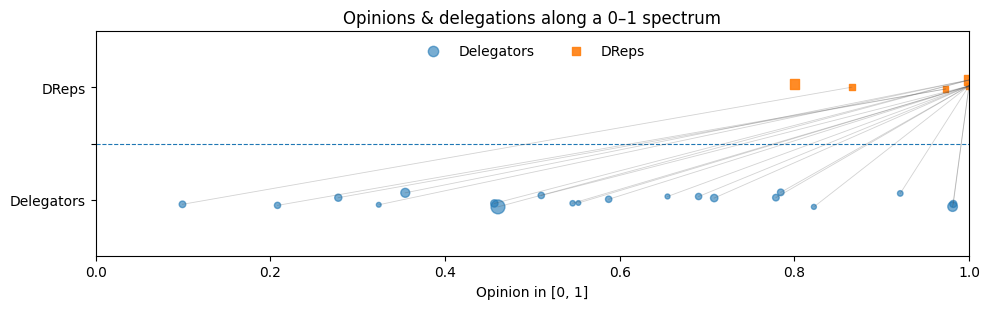

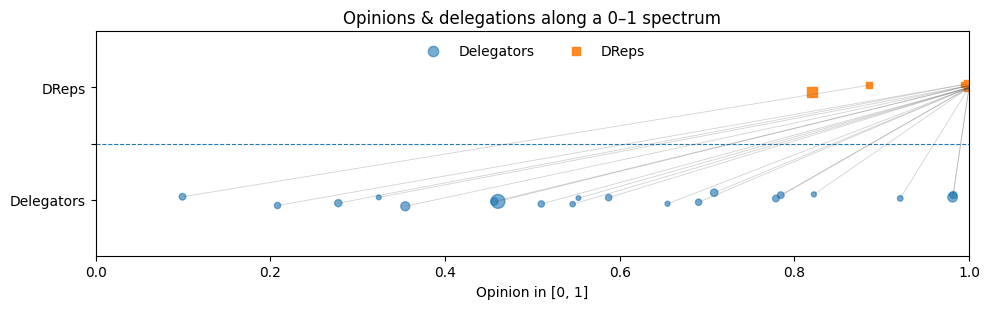

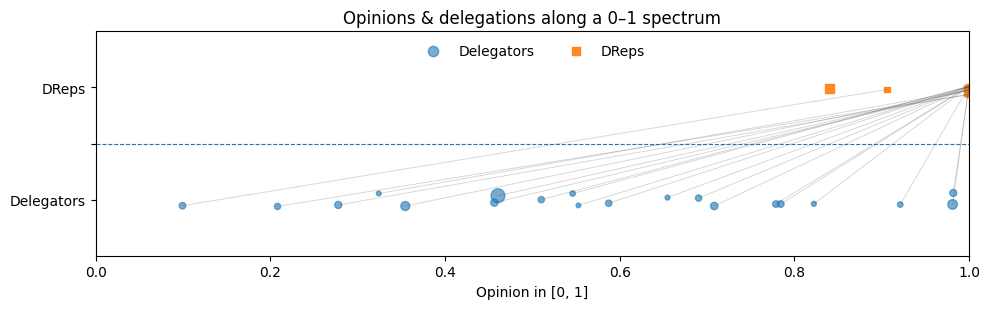

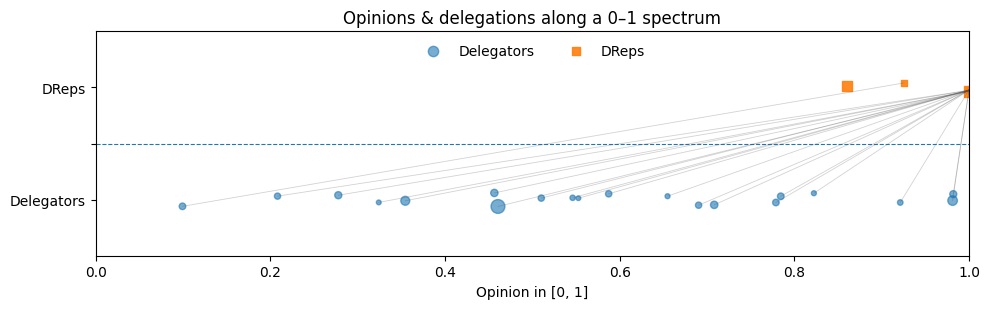

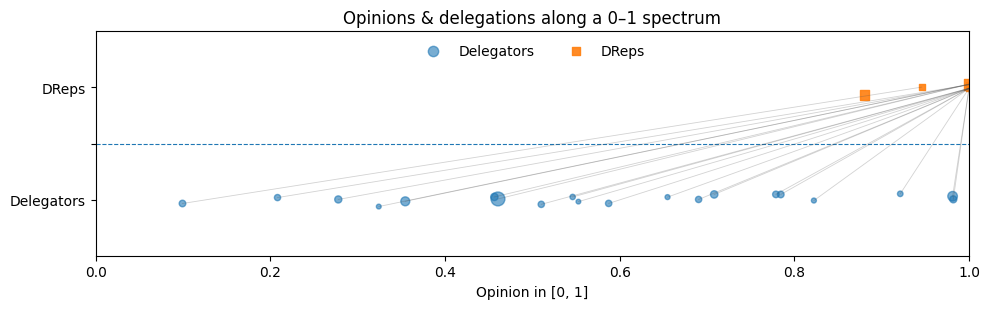

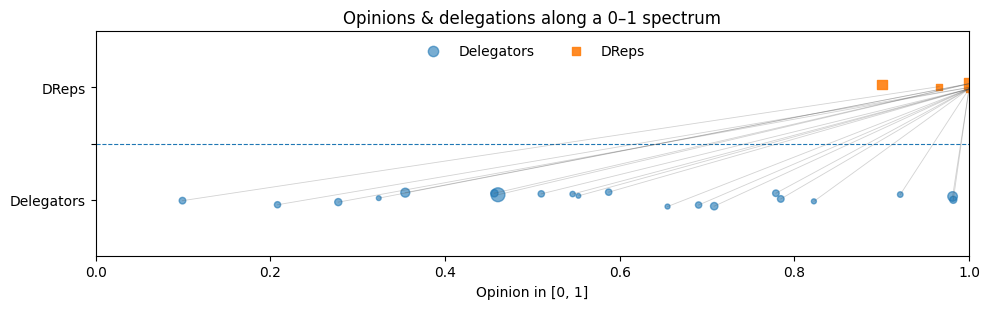

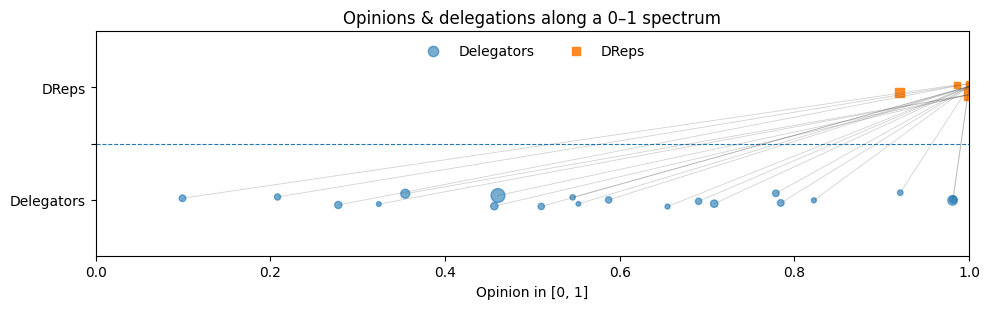

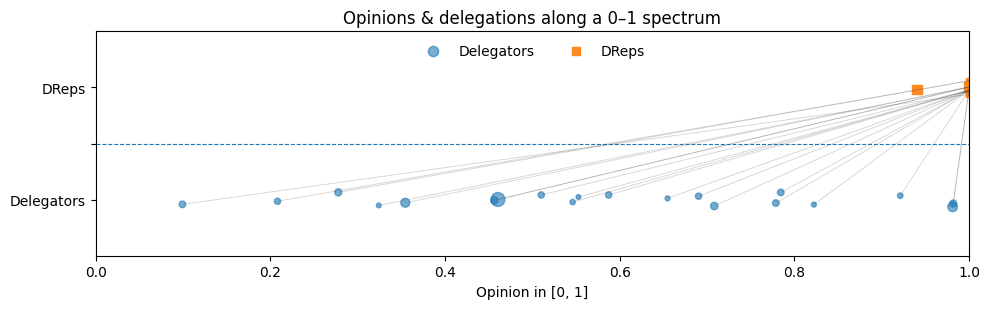

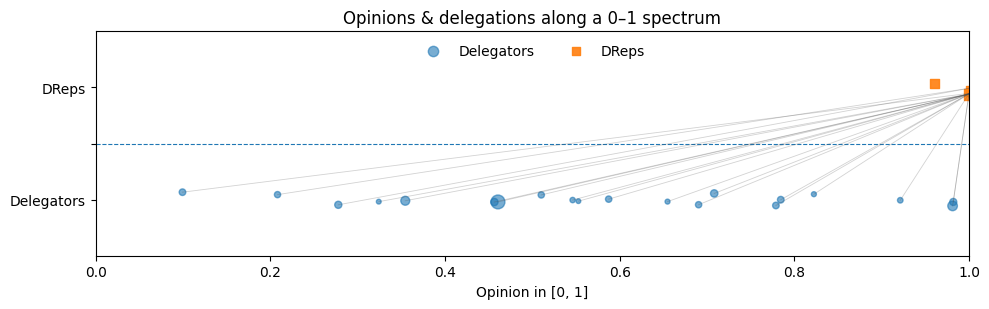

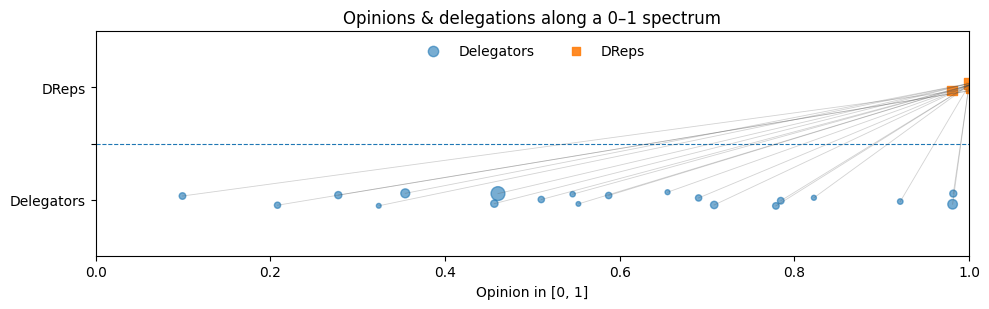

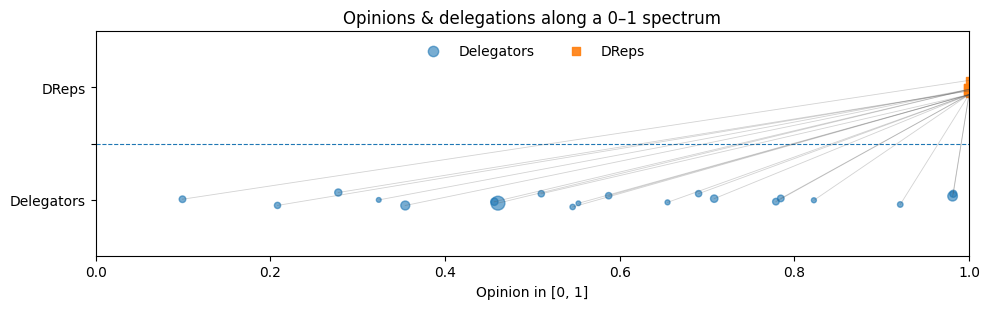

In [139]:
results = simulate_large()
agg = aggregate_metrics(results)

print("Approval rate per epoch (direct):   ", [round(x,3) for x in agg["direct_rate"]])
print("Approval rate per epoch (delegated):", [round(x,3) for x in agg["delegated_rate"]])
print("Fraction switched per epoch:", [round(x,3) for x in agg["switched_frac"]])
print("Top-5 W' share per epoch:   ", [round(x,3) for x in agg["top5_share"]])
